# 2026.10.6(화) 21h~

In [2]:
# !pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 MB 37.2 MB/s eta 0:00:00m eta 0:00:010:00:01
  Installindone
  Getting requirements to build wheel ... one
  Preparing metadata (pyproject.toml) ... one
^C
anceled


네, 꽤 오래 걸릴 수 있어요 (보통 10~30분, 환경에 따라 더 걸릴 수도 있음) -> 왜 오래 걸리는가?
- 정상적인 경우 pip install opencv-python은 미리 컴파일된 wheel(.whl)을 다운로드해서 바로 설치됩니다.
- 그런데 로그를 보면 opencv_python-5.0.0.93.tar.gz를 받아서 Building wheels for collected packages: opencv-python가 뜨고 있어요 — 이건 소스 코드를 직접 빌드하는 중이라는 뜻입니다. 즉 지금 쓰시는 환경(Python 3.13, anaconda3)에 맞는 prebuilt wheel이 PyPI에 없어서 OpenCV 전체를 C++로 컴파일하고 있는 상황이에요.
- OpenCV 소스 빌드는 용량도 크고(81.8MB 소스 + 의존 라이브러리들) CMake/컴파일러가 필요해서 시간이 꽤 걸리고, 빌드 도구가 없으면 중간에 에러로 실패할 수도 있습니다

In [1]:
# !pip install opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 MB 34.0 MB/s eta 0:00:00m eta 0:00:010:00:01
  Installing builddone
  Getting requirements to build wheel ... one
  Preparing metadata (pyproject.toml) ... one
-

In [1]:
# !conda install -c conda-forge opencv

Jupyter detected...
2 channel Terms of Service accepted
Retrieving noticesdone
Channels:
 - conda-forge
 - defaults
Platform: osx-64
doneng package metadata (repodata.json): / 
^Clving environment: \ 


In [1]:
# !conda install -n base conda-libmamba-solver -y
# !conda install -c conda-forge opencv --solver=libmamba -y

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-64
doneecting package metadata (repodata.json): - 
doneing environment: \ 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-64
doneecting package metadata (repodata.json): - 
^Clving environment: | 


In [2]:
!pip download opencv-python-headless==4.9.0.80 -d /tmp/cvcheck --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 MB 38.8 MB/s eta 0:00:0031m42.9 MB/s eta 0:00:01
Saved /private/tmp/cvcheck/opencv_python_headless-4.9.0.80-cp37-abi3-macosx_10_16_x86_64.whl
Successfully downloaded opencv-python-headless


In [1]:
# !pip install opencv-python-headless==4.9.0.80

  Using cached opencv_python_headless-4.9.0.80-cp37-abi3-macosx_10_16_x86_64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.9.0.80-cp37-abi3-macosx_10_16_x86_64.whl (55.7 MB)


In [3]:
import sys; print(sys.executable)

/opt/anaconda3/envs/voice-ai/bin/python


In [4]:
import sys
print(sys.executable)  # 확인용, voice-ai 경로 나오는지
!{sys.executable} -m pip install opencv-python-headless==4.9.0.80

/opt/anaconda3/envs/voice-ai/bin/python
  Using cached opencv_python_headless-4.9.0.80-cp37-abi3-macosx_10_16_x86_64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.9.0.80-cp37-abi3-macosx_10_16_x86_64.whl (55.7 MB)


In [3]:
import tensorflow as tf
import sys
import os
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import numpy as np
import cv2

model = load_model('./model1006/09-0.0598.keras')
#model = load_model('/content/model_cnn/15-0.0595.hdf5 ')#colab의 경우
model.summary()

test_num1 = cv2.imread('./No_Img/3.png')
test_num2 = cv2.imread('./No_Img/5.jpg')
test_num3 = cv2.imread('./No_Img/7.jpg')
#colab의 예
#test_num3 = cv2.imread(‘/content/drive/MyDrive/Colab Notebooks/Model/minist_test/5.jpg ')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

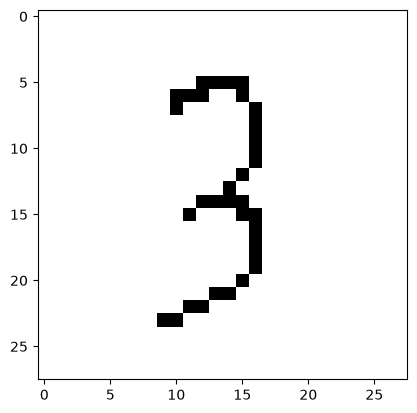

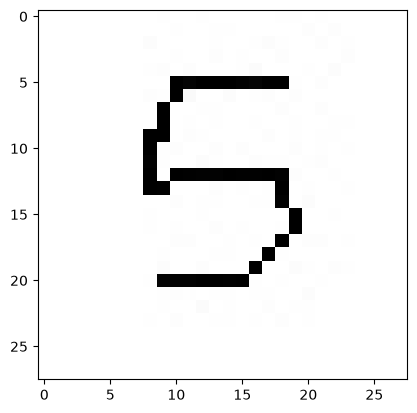

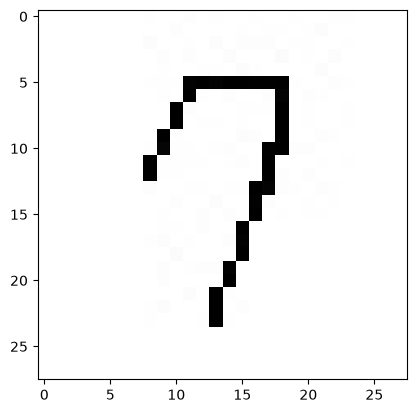

In [4]:
#RGB file을 gray로
test_num1 = cv2.cvtColor(test_num1, cv2.COLOR_BGR2GRAY)
test_num2 = cv2.cvtColor(test_num2, cv2.COLOR_BGR2GRAY)
test_num3 = cv2.cvtColor(test_num3, cv2.COLOR_BGR2GRAY)
#위 과정을 거치면 색상이 반전됨 -> 아래에서 색상을 다시 반전
test_num1 = 255 - test_num1
test_num2 = 255 - test_num2
test_num3 = 255 - test_num3

plt.imshow(test_num1, cmap='Greys');
plt.show()
plt.imshow(test_num2, cmap='Greys');
plt.show()
plt.imshow(test_num3, cmap='Greys');
plt.show()


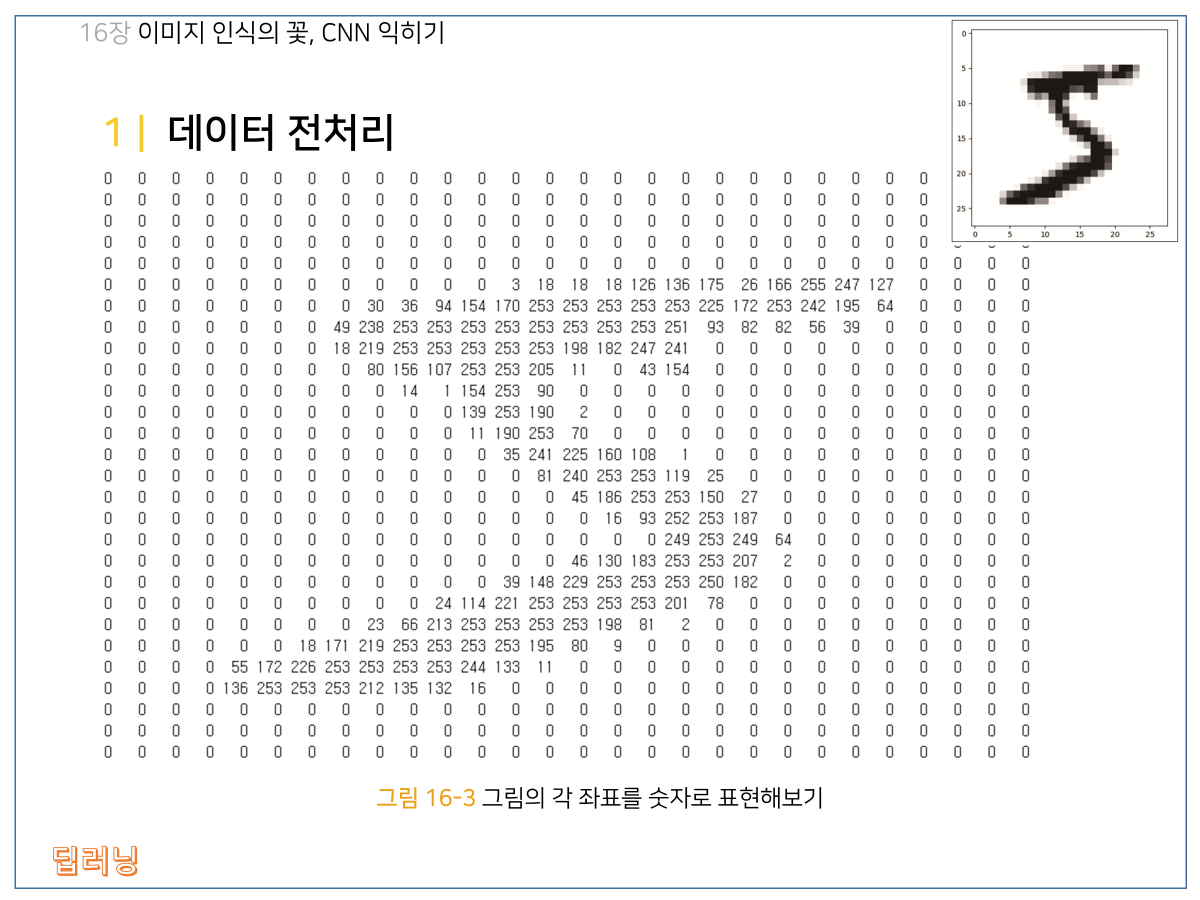

In [5]:
import sys
for x in test_num1:
    for i in x:
        # sys.stdout.write('%d\t' % i)
        sys.stdout.write('%3d' % i)
    sys.stdout.write('\n')


  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0255255255255  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0255255255  0  0255  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0255  0  0  0  0  0255  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0255  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0255  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0255  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0255  0  0  0  0  

In [6]:

test_num1 = test_num1.reshape(1, 784).astype('float64') / 255
test_num2 = test_num2.reshape(1, 784).astype('float64') / 255
test_num3 = test_num3.reshape(1, 784).astype('float64') / 255

#print('The Answer 3 is ', model.predict_classes(test_num1))
#print('The Answer 6 is ', model.predict_classes(test_num2))
#print('The Answer 5 is ', model.predict_classes(test_num3))

#print('The Answer 3 is ', model.predict_classes(test_num1))
#print('The Answer 6 is ', model.predict_classes(test_num2))
#print('The Answer 5 is ', model.predict_classes(test_num3))

#model.predict_classes는 아래 코드와 동일한 역할을 함

test_predict= list()
test_predict.append(model.predict(test_num1))
test_predict.append(model.predict(test_num2))
test_predict.append(model.predict(test_num3))
print('The Answer 3 is ', test_predict[0].argmax())
print('The Answer 5 is ', test_predict[1].argmax())
print('The Answer 7 is ', test_predict[2].argmax())



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
The Answer 3 is  3
The Answer 5 is  5
The Answer 7 is  7
